In [1]:
from hardware import SLMManager
import torch

sim_mode = True
slm_manager = SLMManager(sim_mode=sim_mode)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')



🎬 Simulation Mode Enabled


In [2]:
import config
from optics_utils import process_parameters
from phase_generators import PhaseGenerator
# 默认参数字典 from config
test_raw_params = {}
test_raw_params.update(config.COMMON_DEFAULTS)
test_raw_params.update(config.OPTIMIZED_DEFAULTS)
test_raw_params.update(config.INTERNAL)

# 添加测试需要的基本信息 (这些信息之前GUI提供)
test_raw_params['shape'] = slm_manager.shape
test_raw_params['N'] = 900 # ROI尺寸

# fix
test_raw_params['focal_length_coarse'] = 58.5

# 调用参数处理函数
final_params = process_parameters(test_raw_params)

# Fresnel lens 
Optimizer2 = PhaseGenerator(final_params, device=device)
Optimizer2.generate(mode='fresnel')
phase_8bit = Optimizer2.update_phase_8bit(215)
if not sim_mode:
    slm_manager.upload(phase_8bit)

Using device: cpu
F/49.46, 58.5 mm
Lens width: 1.183mm
Airy radius: 32.1um
Depth of focus: 2.60mm
Multi-depth planes are used at F=55.9 (-1.0DOF), 61.1 (1.0DOF) mm
Out-of-focus planes are used at Z=52.7 (0.90x), 43.9 (0.75x), 29.2 (0.50x), 14.6 (0.25x), 0.6 (0.01x) mm
Fresnel Lens: 900x900 px; 7x7 lenses


Using device: cpu
F/49.46, 58.5 mm
Lens width: 1.183mm
Airy radius: 32.1um
Depth of focus: 2.60mm
Multi-depth planes are used at F=55.9 (-1.0DOF), 61.1 (1.0DOF) mm
Out-of-focus planes are used at Z=52.7 (0.90x), 43.9 (0.75x), 29.2 (0.50x), 14.6 (0.25x), 0.6 (0.01x) mm


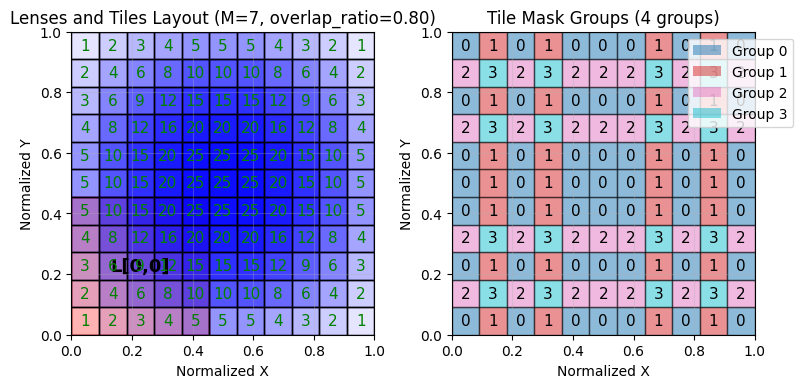


Tile Statistics:
Total tiles: 121
Grid dimensions: 13 x 13
Tiles per group: {0: 49, 1: 28, 2: 28, 3: 16}
Lens contribution distribution: {1: 4, 2: 8, 3: 8, 4: 12, 5: 12, 6: 8, 8: 8, 10: 12, 9: 4, 12: 8, 15: 12, 16: 4, 20: 12, 25: 9}


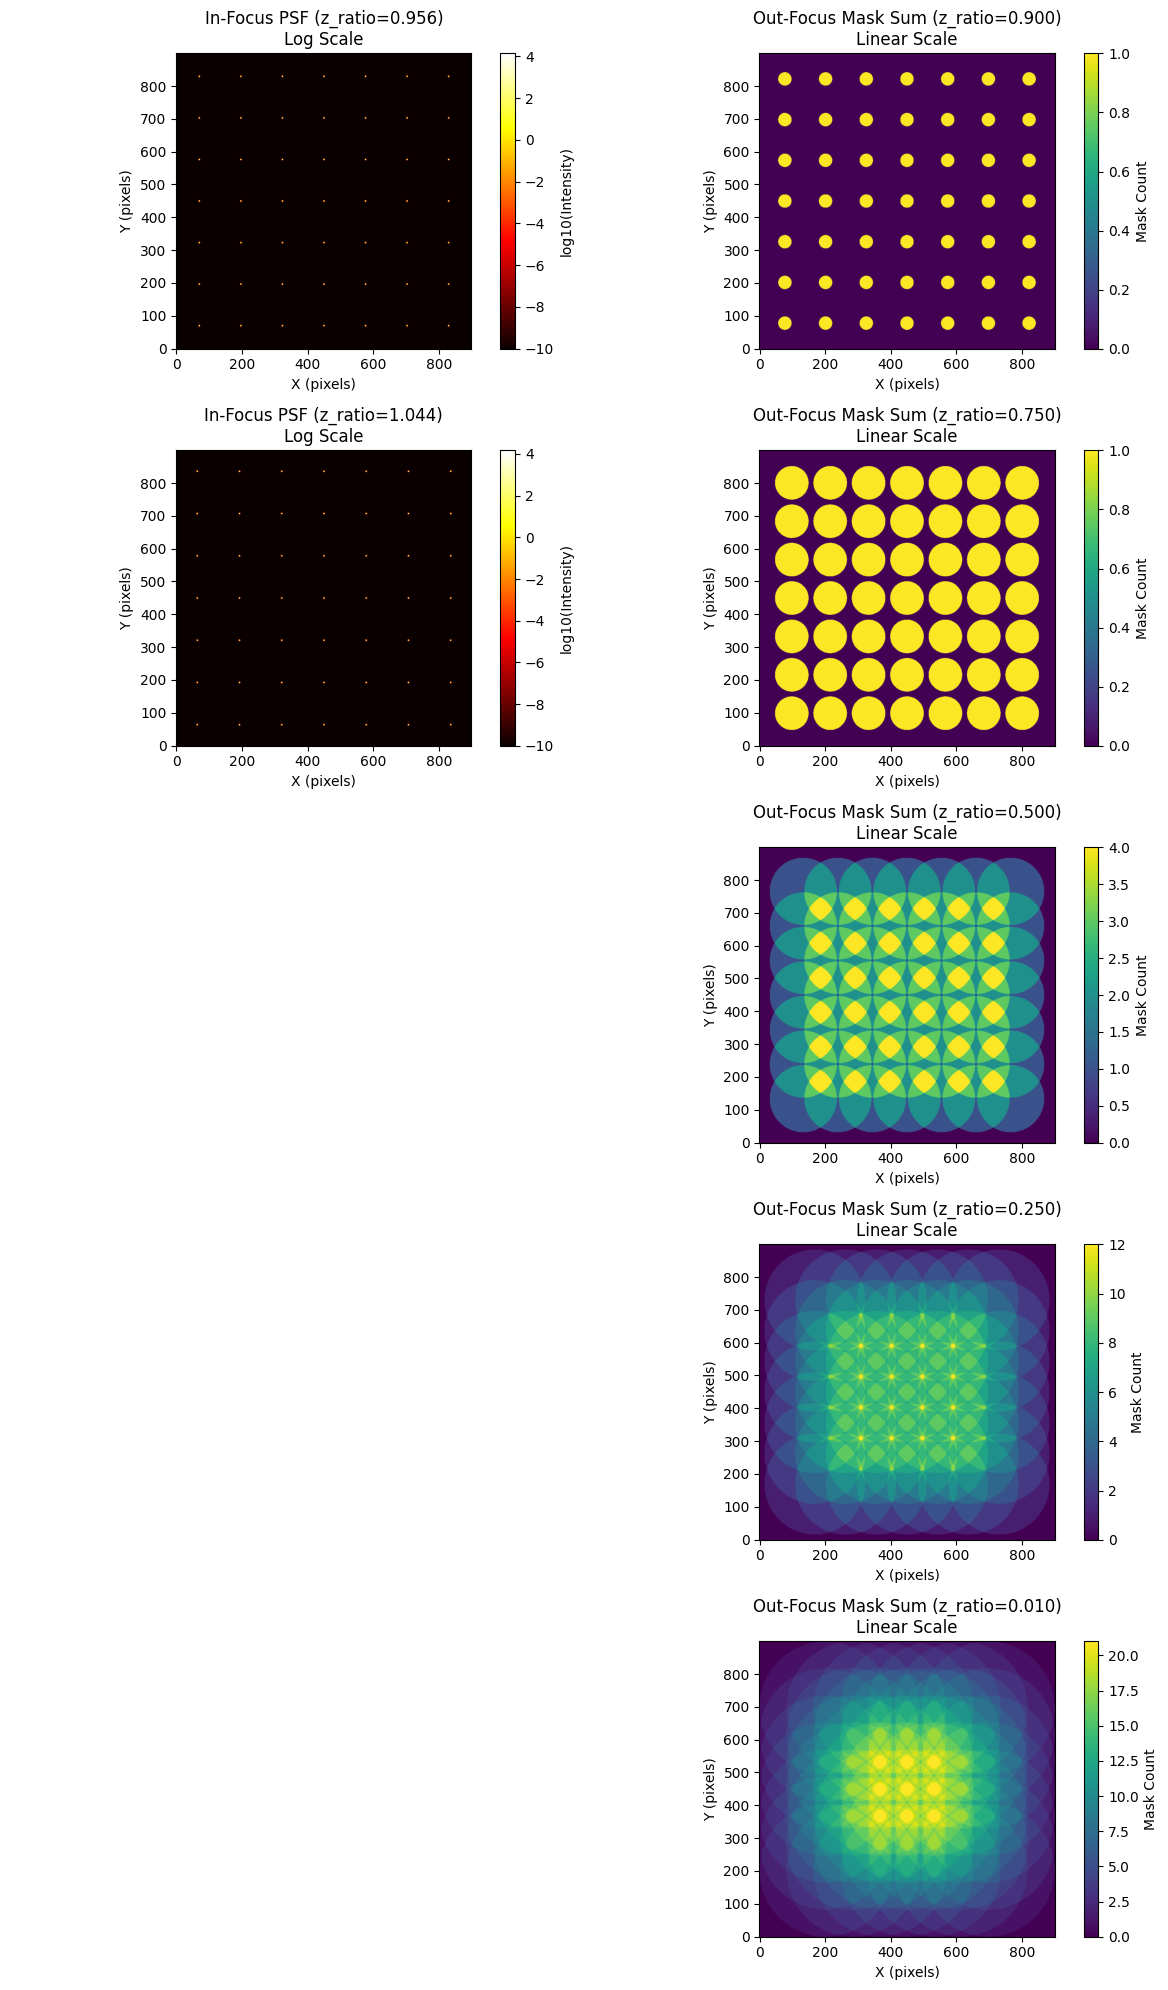

In [3]:
# Optimization prepare
final_params['overlap_ratio'] = 0.8
final_params['airy_correction'] = 0.9
final_params['mask_count'] = 4
final_params['interleaving'] = 'coarse2'
Optimizer = PhaseGenerator(final_params, device=device) 
Optimizer._prepare_template()


In [4]:
Optimizer.generate(upsampling=2.0, visualize=False)
phase_8bit = Optimizer.update_phase_8bit(215)
if not sim_mode:
    slm_manager.upload(phase_8bit)

RuntimeError: [enforce fail at alloc_cpu.cpp:121] data. DefaultCPUAllocator: not enough memory: you tried to allocate 3175200000 bytes.

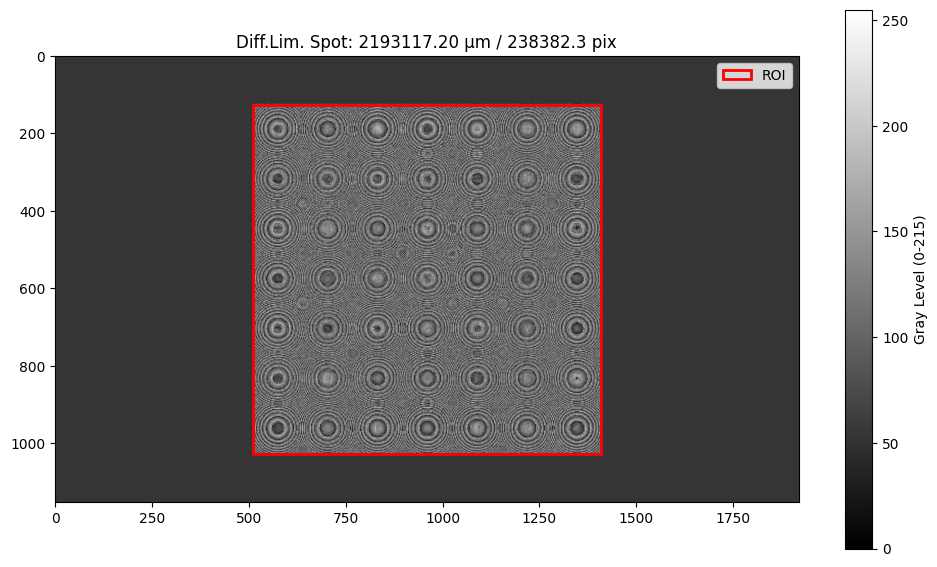

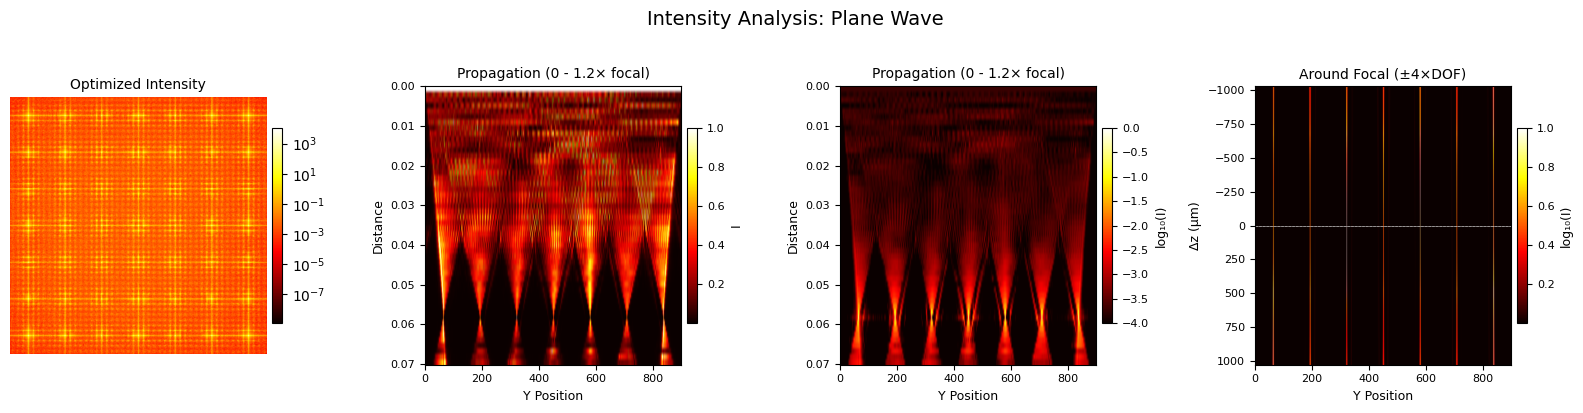

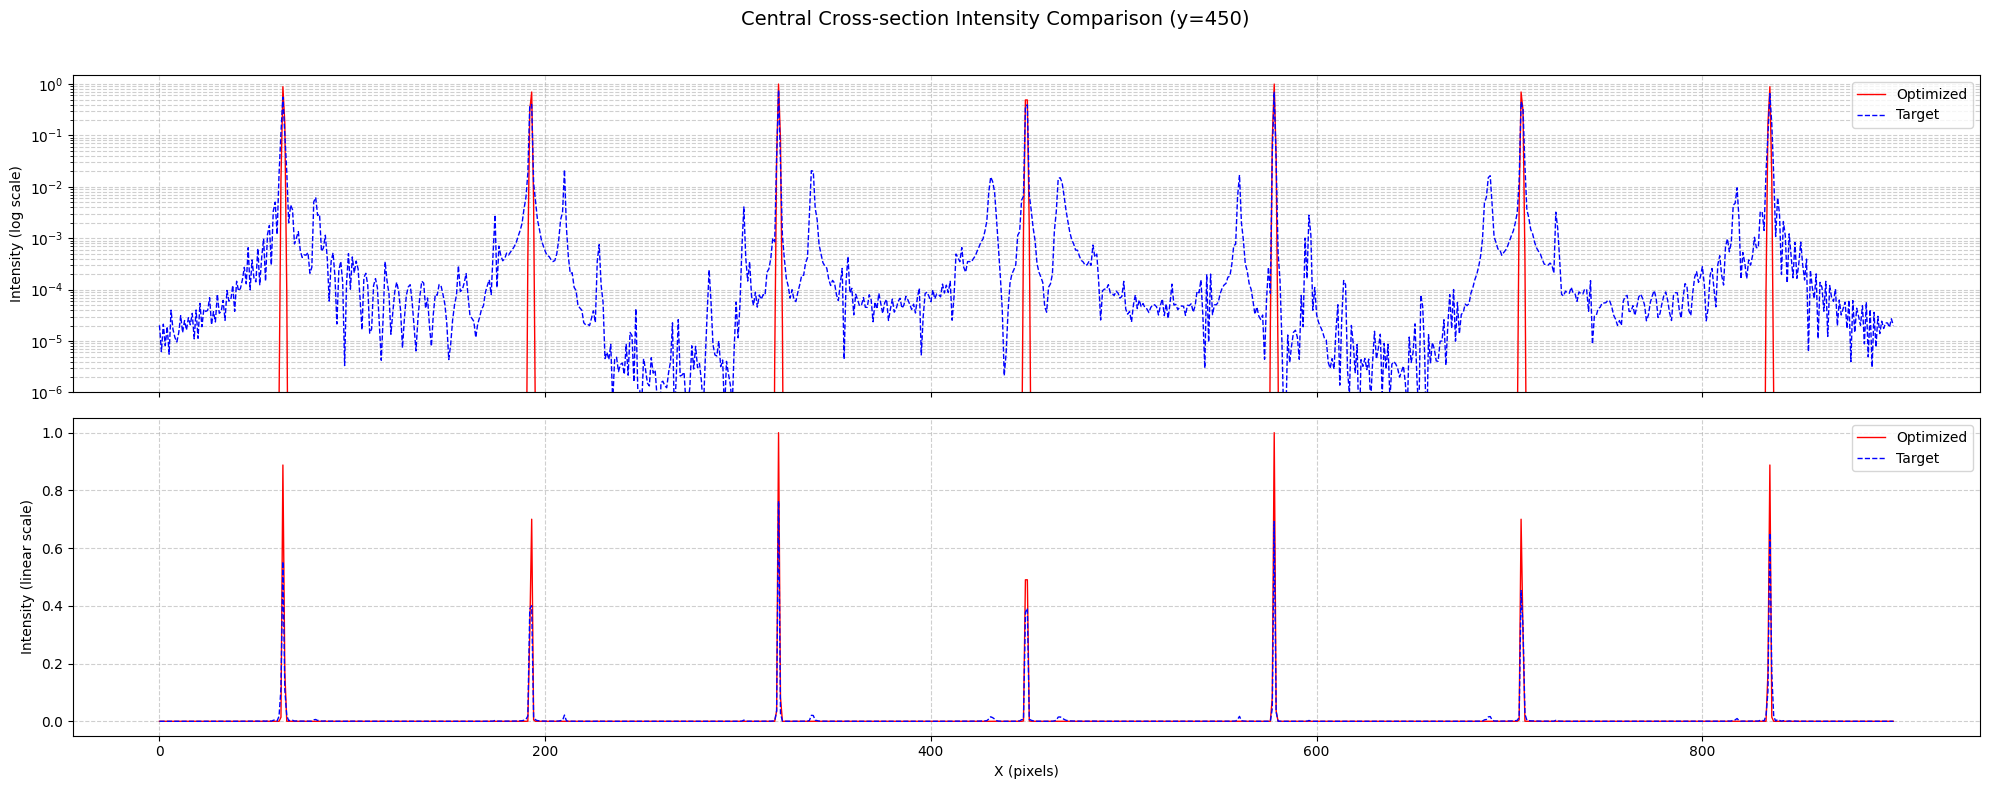

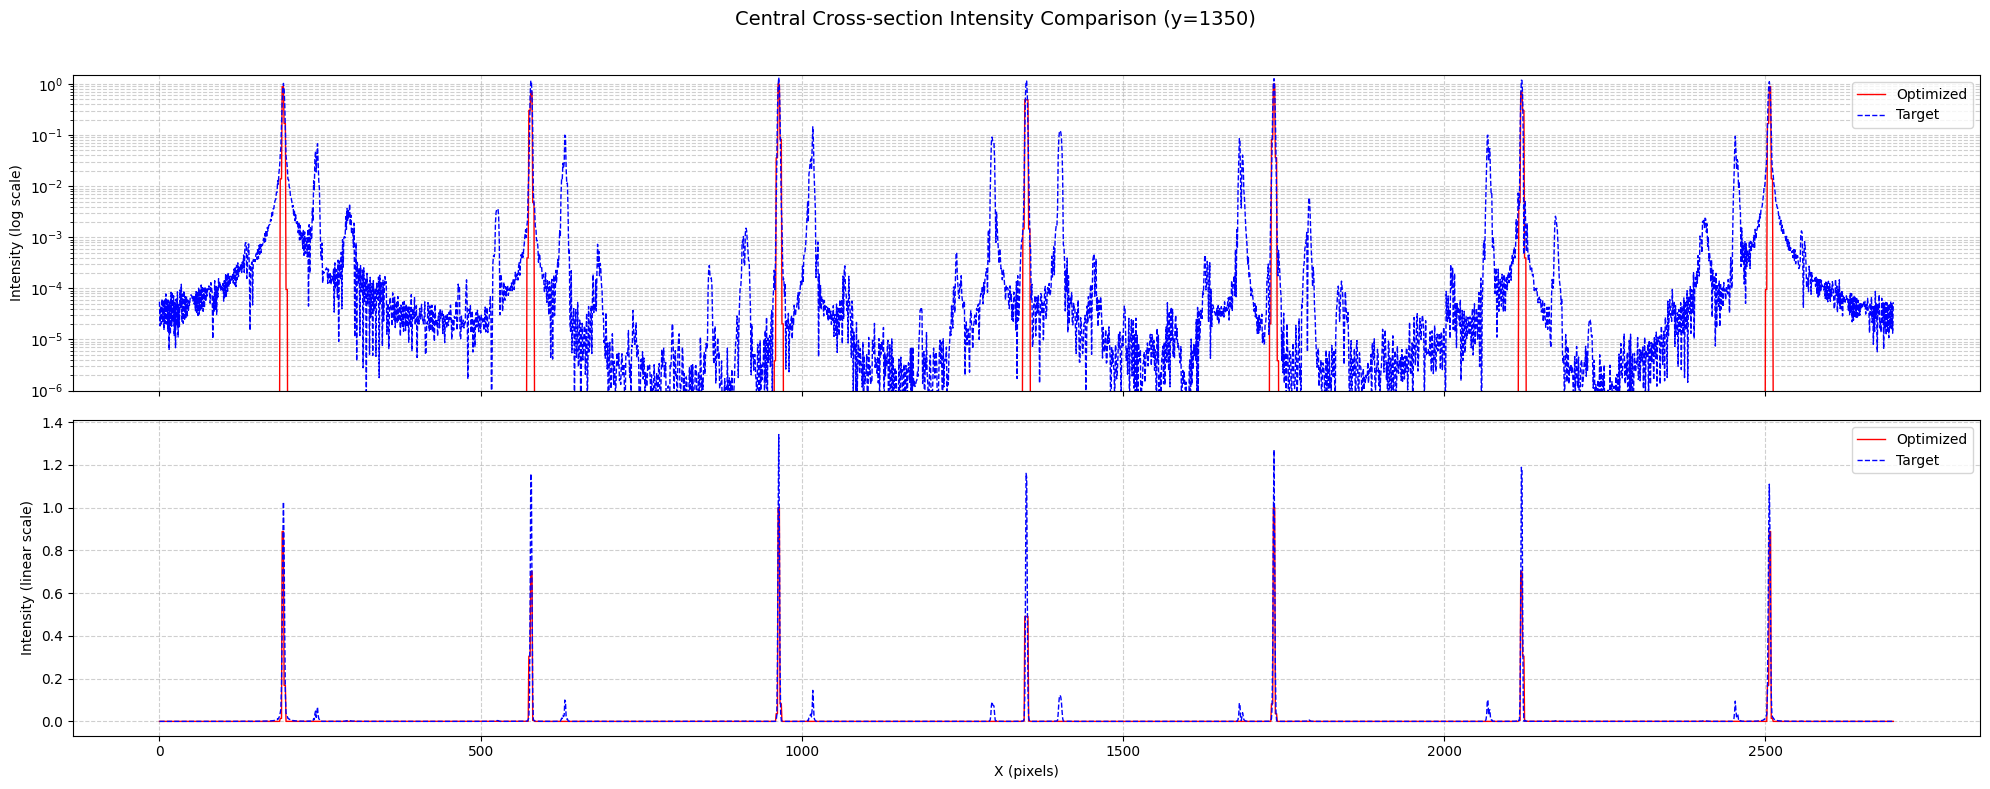

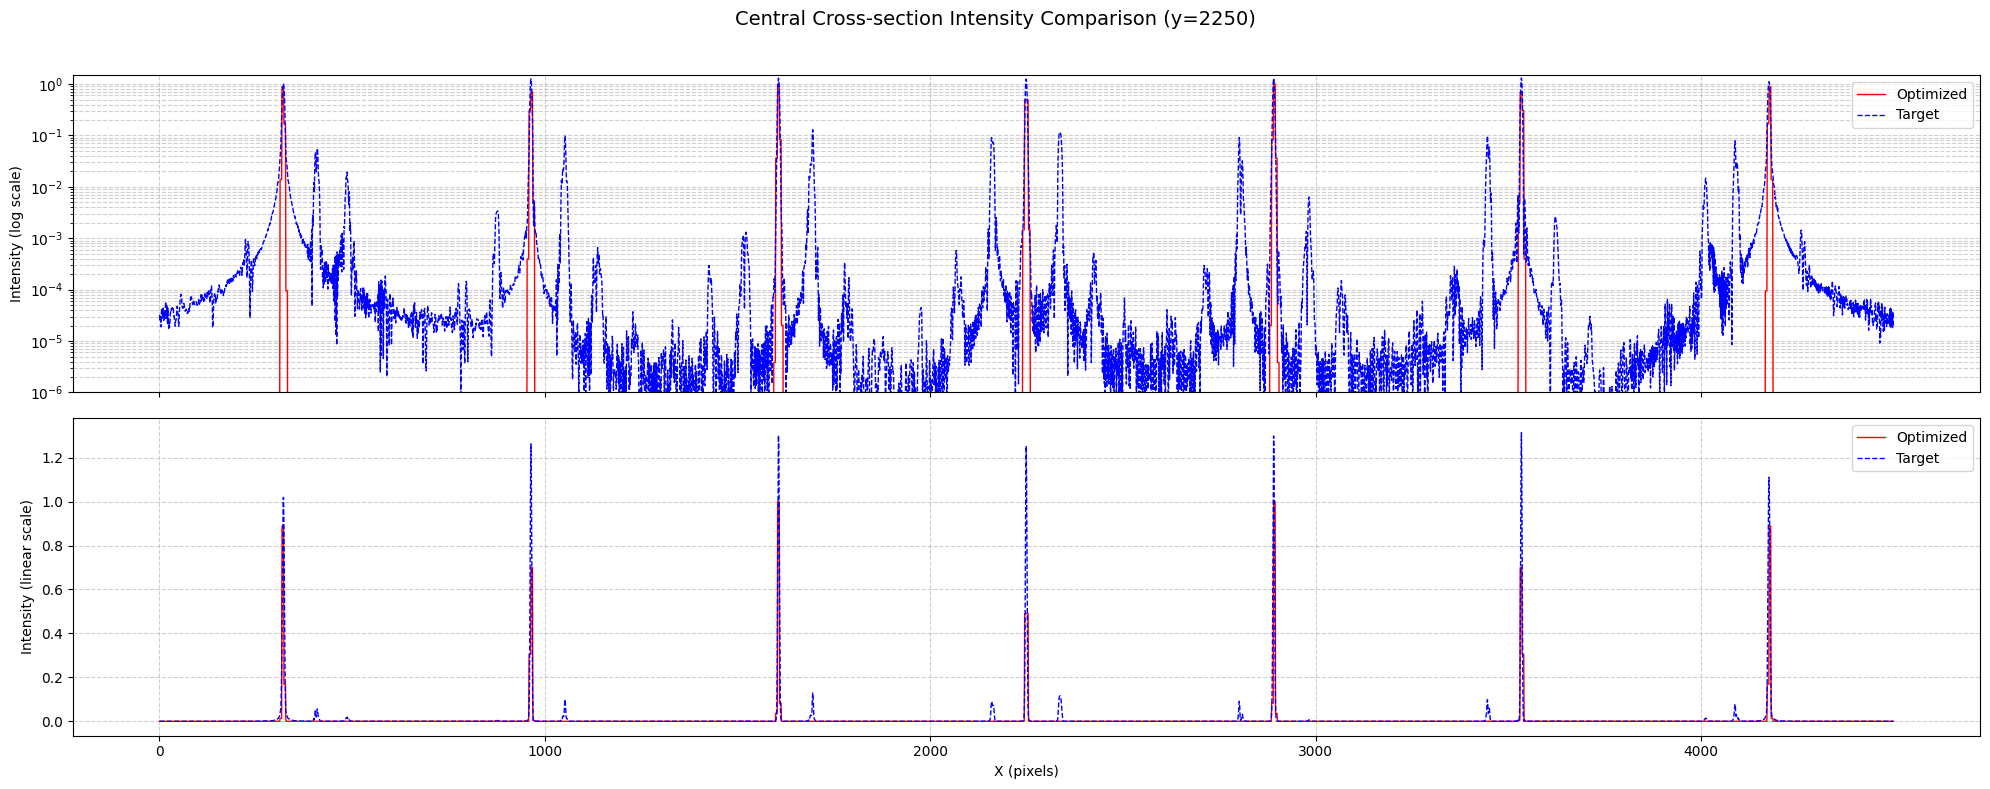

Encircled energy radius used for calculation: 1.10 pixels


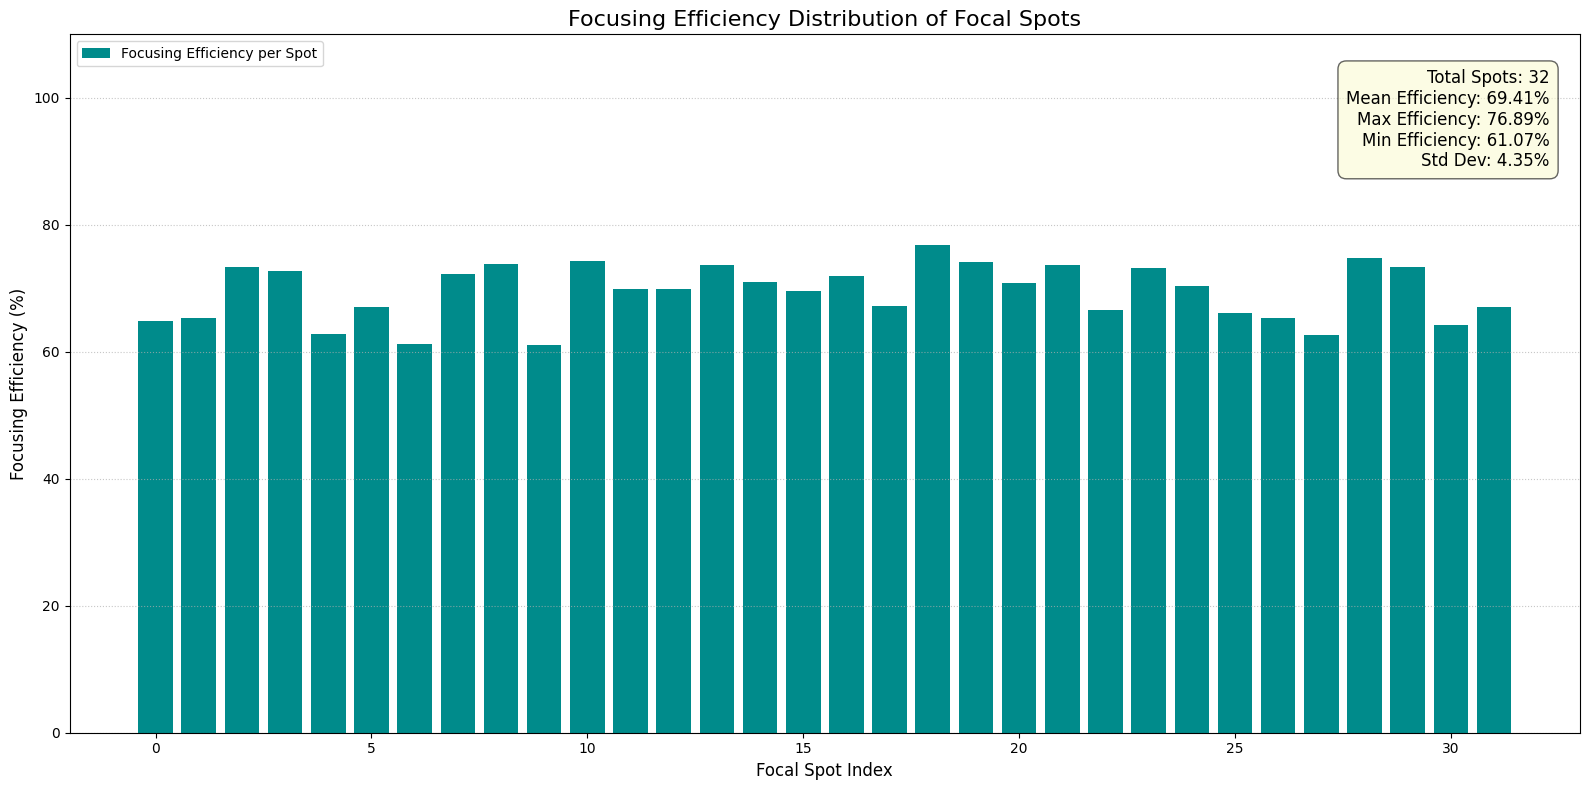

Encircled energy radius used for calculation: 3.29 pixels


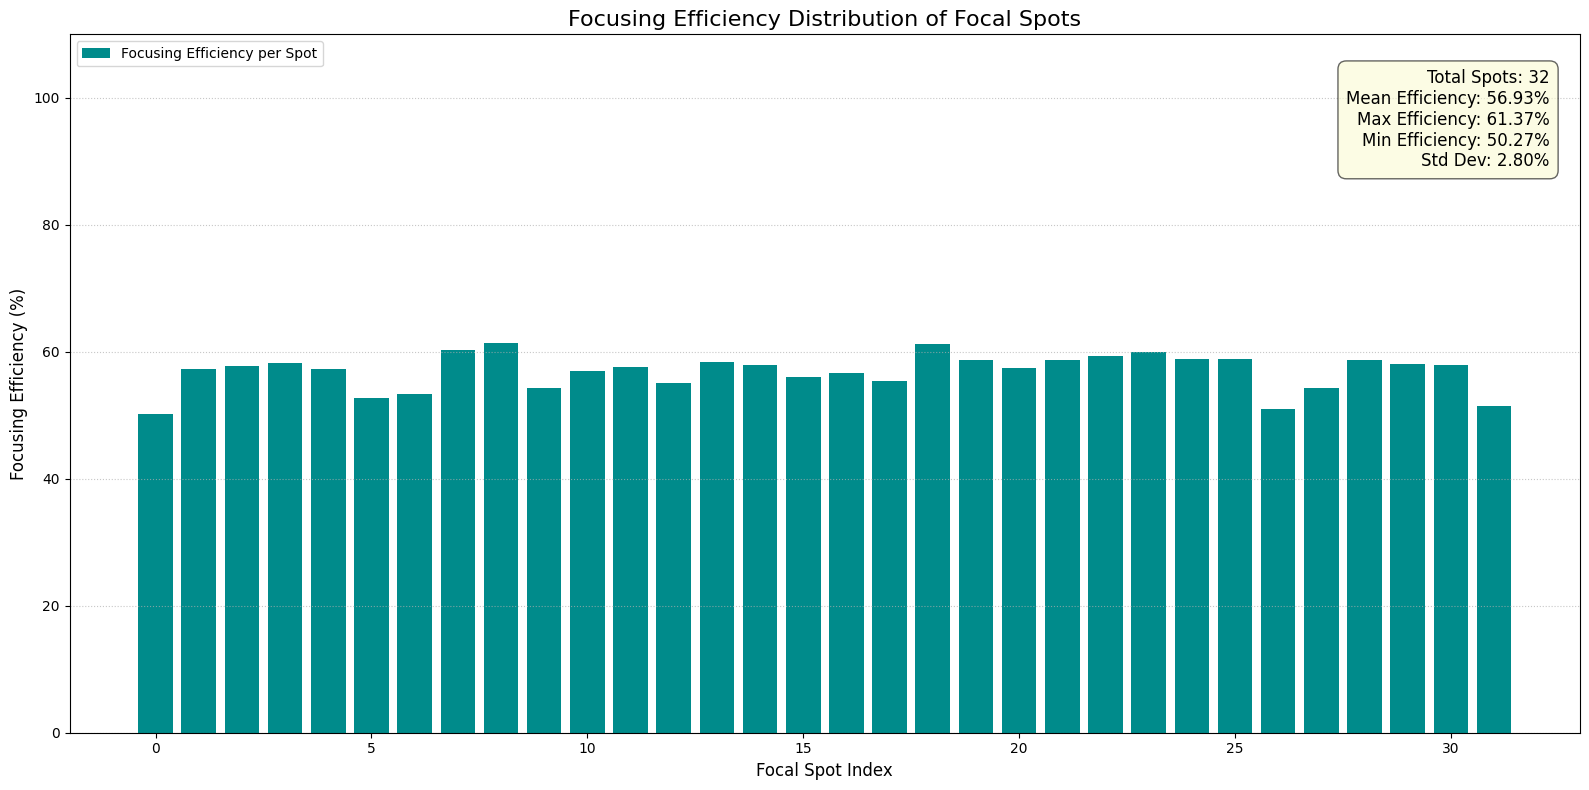

Encircled energy radius used for calculation: 5.48 pixels


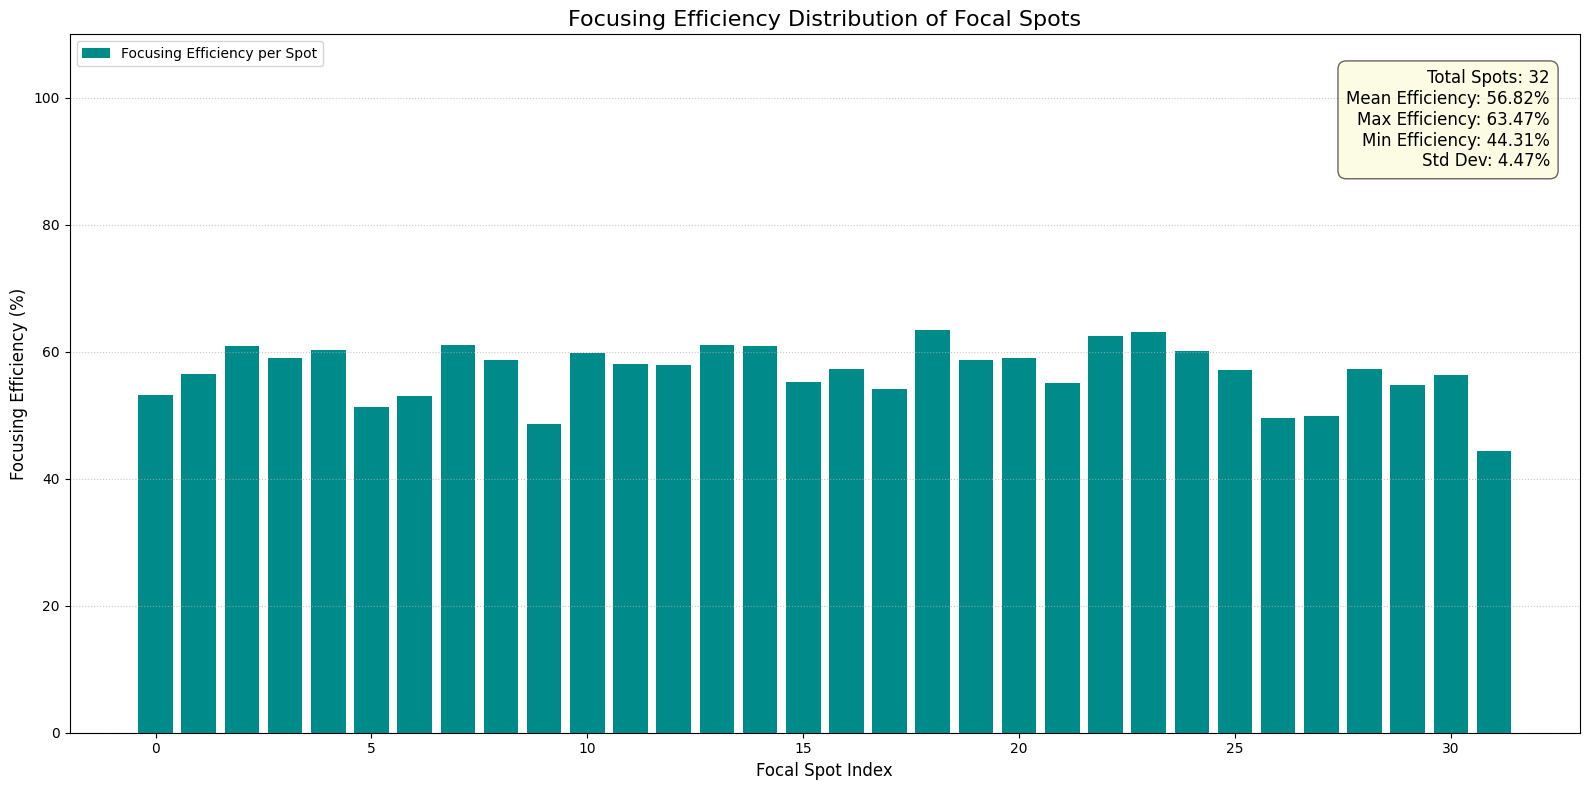

In [ ]:
from visualization import plot_phase,plot_2d_comparisons, plot_cross_sections, plot_energy_distribution
# 可视化
plot_phase(Optimizer)
plot_2d_comparisons(Optimizer)
plot_cross_sections(Optimizer,upsampling=1.0)
plot_cross_sections(Optimizer,upsampling=3)
plot_cross_sections(Optimizer,upsampling=5)

plot_energy_distribution(Optimizer,upsampling=1)
plot_energy_distribution(Optimizer,upsampling=3)
plot_energy_distribution(Optimizer,upsampling=5)
